
# Sprint 1 - Data Understanding & Preprocessing
## Mental Tiredness Prediction Project

### Goal
Convert raw data into a clean and model-ready dataset for machine learning.



# Step 1: Import Required Libraries

### Description
These libraries are used for:
- **pandas & numpy** → data handling
- **matplotlib & seaborn** → visualization
- **sklearn** → preprocessing and train-test split


In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')



# Step 2: Load Dataset

### Description
The dataset is loaded using pandas.  
We first verify:
- Number of rows and columns
- Whether data loaded correctly
- Initial structure of dataset


In [2]:

df = pd.read_csv('mental_tiredness_score_prediction_dataset.csv.csv')

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (15000, 18)


,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
0,110,14,70,196.5,65.1,7.0,136.1,1,7.84,26.75,2.05,Happy,Remote,Moderate Noise,53.8,19.8,3.3,22.17
1,122,9,66,256.4,135.2,6.5,83.9,3,7.18,17.82,1.82,Low,Remote,Noisy,38.9,18.7,4.6,25.35
2,113,4,55,387.3,54.2,10.0,176.5,5,5.52,27.78,1.92,Happy,Office,Quiet,42.0,26.4,7.9,34.36
3,113,8,45,300.3,107.1,4.8,164.7,2,8.47,3.48,1.89,Happy,Manual,Quiet,47.2,23.8,5.4,11.92
4,95,8,68,240.5,3.2,8.0,186.3,4,7.48,21.17,2.41,Happy,Manual,Moderate Noise,61.0,24.2,8.5,37.45



### Output Description
- **Dataset Shape** shows total rows and columns.
- `head()` displays the first 5 records.
- Helps verify whether all columns are loaded properly.



# Step 3: Initial Data Inspection

### Description
This step helps us understand:
- Data types
- Missing values
- Numerical statistics
- Data consistency


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   number_of_decisions_made  15000 non-null  int64  
 1   context_switch_count      15000 non-null  int64  
 2   notifications_received    15000 non-null  int64  
 3   screen_time_min           15000 non-null  float64
 4   deep_work_min             15000 non-null  float64
 5   task_complexity_avg       15000 non-null  float64
 6   caffeine_mg               15000 non-null  float64
 7   break_frequency           15000 non-null  int64  
 8   sleep_hours               15000 non-null  float64
 9   deep_sleep_pct            15000 non-null  float64
 10  hydration_l               15000 non-null  float64
 11  mood                      15000 non-null  object 
 12  work_type                 15000 non-null  object 
 13  work_environment          15000 non-null  object 
 14  noise_


### Output Description
`info()` provides:
- Total entries
- Column names
- Data types
- Non-null values

This helps identify:
- Missing values
- Incorrect data types
- Categorical vs numerical columns


In [4]:

df.describe()


,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,noise_level_db,temperature_c,workload_score,mental_tiredness_score
count,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,120.079133,7.982133,64.96780,302.211107,96.698407,5.505333,131.170247,4.001733,6.893889,19.017639,1.892743,47.925353,23.000160,5.697280,25.189109
std,10.882327,2.837784,8.11442,136.575167,61.249273,1.957174,79.542710,2.017358,1.296186,5.958026,0.686356,9.880337,2.967518,1.941123,12.190013
min,82.000000,0.000000,30.00000,20.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.300000,20.000000,15.000000,1.000000,0.000000
25%,113.000000,6.000000,59.00000,205.300000,50.100000,4.175000,72.200000,3.000000,6.010000,15.040000,1.430000,41.300000,21.000000,4.400000,16.690000
50%,120.000000,8.000000,65.00000,302.000000,94.800000,5.500000,129.000000,4.000000,6.900000,18.980000,1.890000,47.900000,23.000000,5.700000,25.220000
75%,127.000000,10.000000,70.00000,396.100000,138.800000,6.800000,185.500000,5.000000,7.780000,23.062500,2.350000,54.600000,25.000000,7.000000,33.460000
max,165.000000,21.000000,101.00000,852.200000,312.800000,10.000000,422.900000,13.000000,11.000000,41.380000,4.570000,84.800000,35.000000,10.000000,76.740000



### Output Description
`describe()` gives statistical summary:
- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles

This helps understand:
- Data spread
- Skewness
- Potential outliers


In [5]:

df.isnull().sum()


number_of_decisions_made    0
context_switch_count        0
notifications_received      0
screen_time_min             0
deep_work_min               0
task_complexity_avg         0
caffeine_mg                 0
break_frequency             0
sleep_hours                 0
deep_sleep_pct              0
hydration_l                 0
mood                        0
work_type                   0
work_environment            0
noise_level_db              0
temperature_c               0
workload_score              0
mental_tiredness_score      0
dtype: int64


### Output Description
This checks missing values in each column.

If any column contains null values:
- We either remove rows
- Or fill values using mean/median/mode


In [6]:

df.duplicated().sum()


np.int64(0)


### Output Description
Checks duplicate records in dataset.

Duplicate rows can:
- Bias the model
- Reduce prediction quality

Duplicates should usually be removed.



# Step 4: Data Cleaning

### Description
We clean the dataset by:
- Removing duplicates
- Standardizing column names


In [7]:

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (15000, 18)



### Output Description
This output shows the dataset size after removing duplicate rows.

If shape decreases:
- Duplicate records existed
- They were successfully removed


In [8]:

df.columns = df.columns.str.lower().str.strip()

df.columns


Index(['number_of_decisions_made', 'context_switch_count',
       'notifications_received', 'screen_time_min', 'deep_work_min',
       'task_complexity_avg', 'caffeine_mg', 'break_frequency', 'sleep_hours',
       'deep_sleep_pct', 'hydration_l', 'mood', 'work_type',
       'work_environment', 'noise_level_db', 'temperature_c', 'workload_score',
       'mental_tiredness_score'],
      dtype='object')


### Output Description
Column names are converted to:
- Lowercase
- Uniform formatting

This improves consistency and avoids coding errors.



# Step 5: Exploratory Data Analysis (EDA)

## Univariate Analysis

### Description
We analyze distribution of each numerical feature individually.


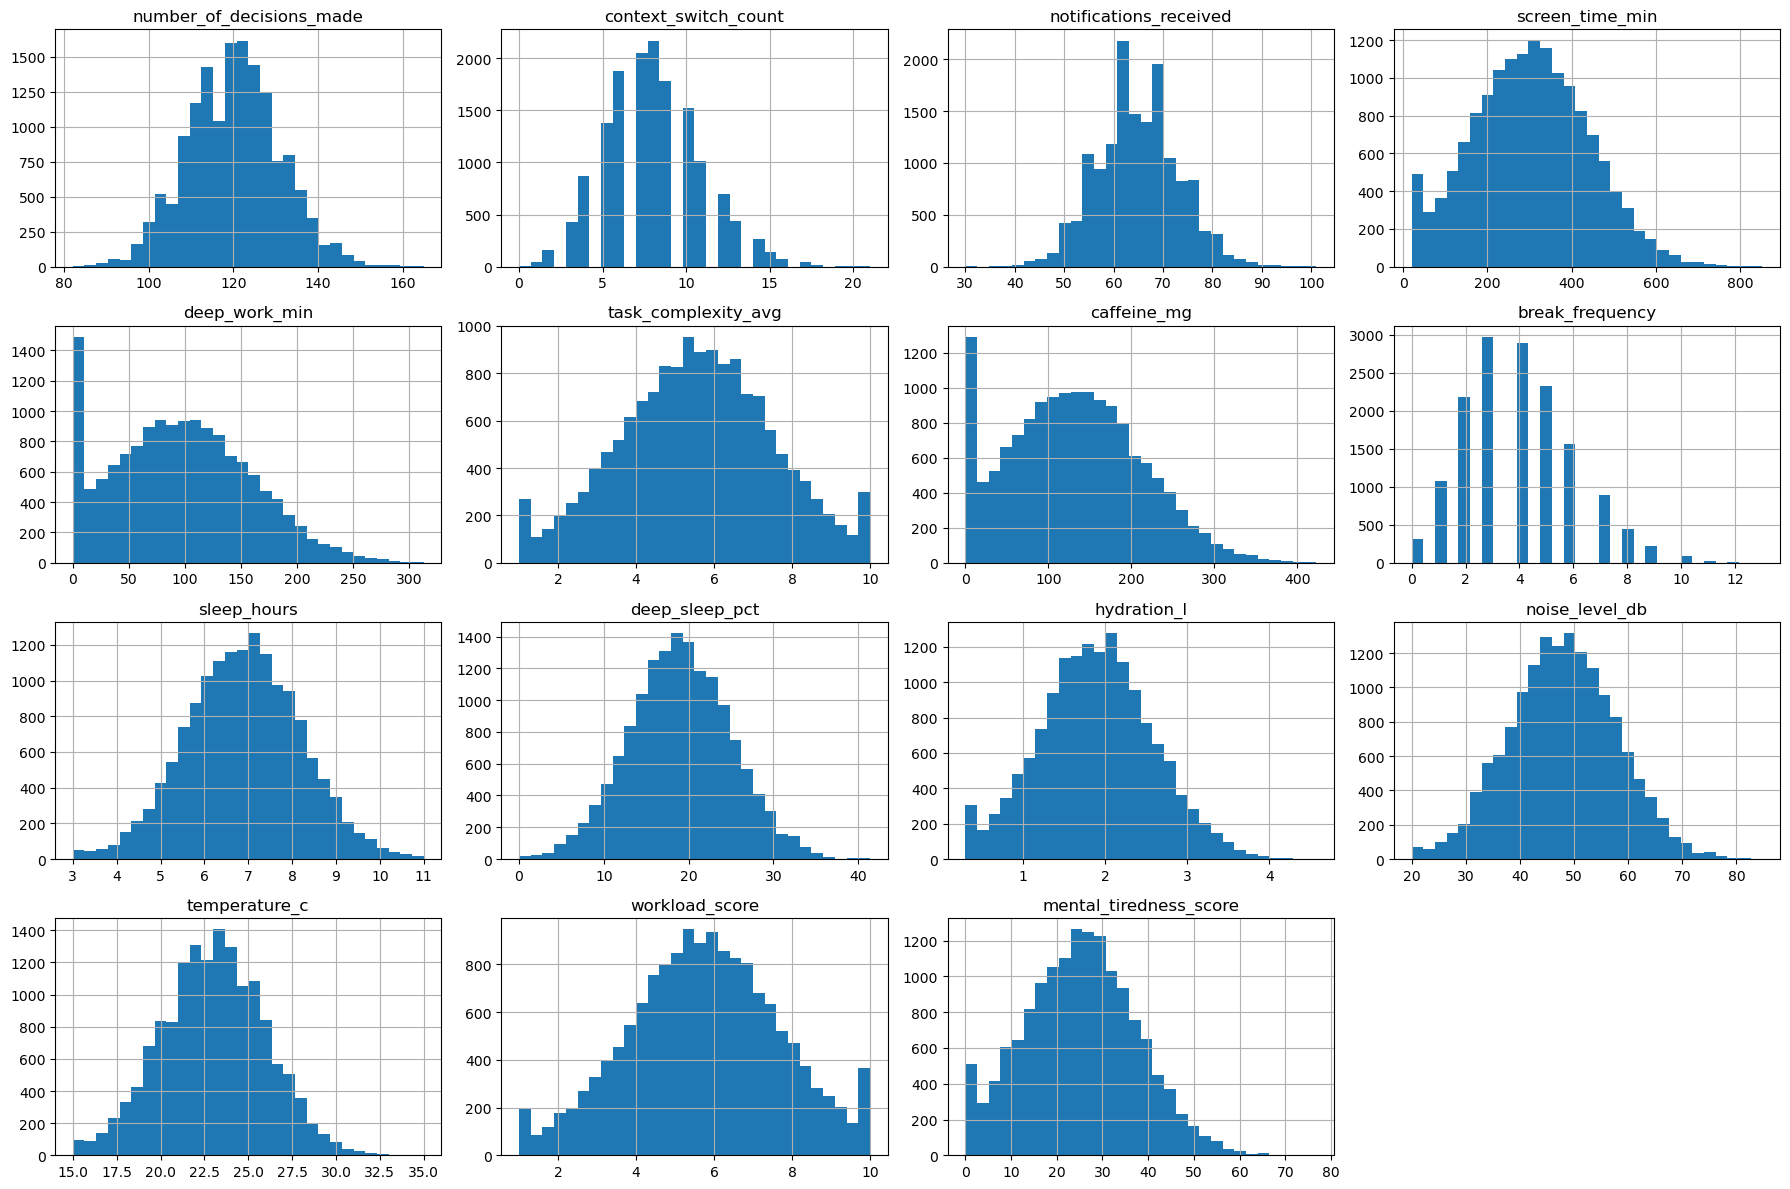

In [9]:

num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(18,12), bins=30)

plt.tight_layout()
plt.show()



### Output Description
Histograms show:
- Feature distribution
- Skewness
- Concentration of values

Useful for:
- Detecting abnormal distributions
- Understanding feature behavior



# Correlation Analysis

### Description
A heatmap helps identify relationships between numerical variables.


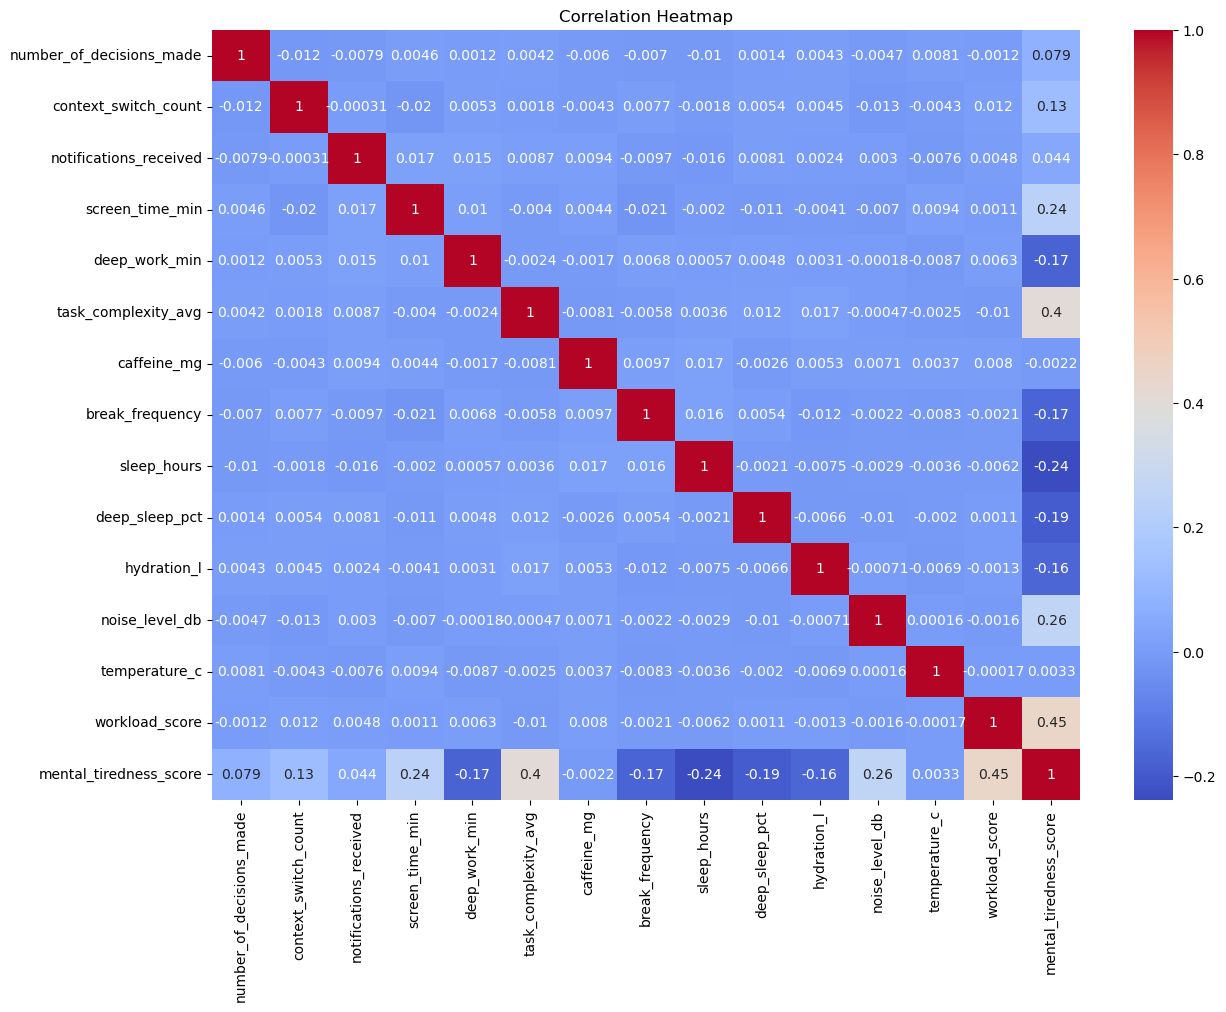

In [10]:

plt.figure(figsize=(14,10))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()



### Output Description
Correlation values range from:
- **+1** → strong positive relation
- **-1** → strong negative relation
- **0** → no relation

This helps identify:
- Features strongly related to target variable
- Multicollinearity between features



# Feature vs Target Relationship

### Description
Scatter plots help analyze how important features affect mental tiredness score.


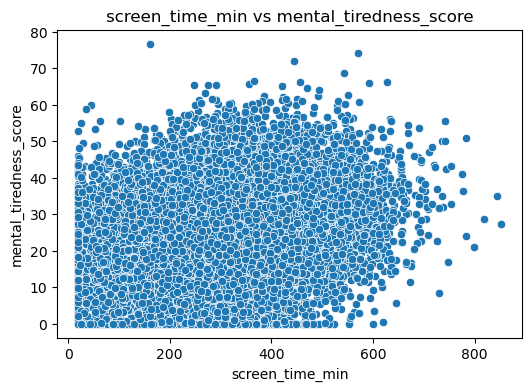

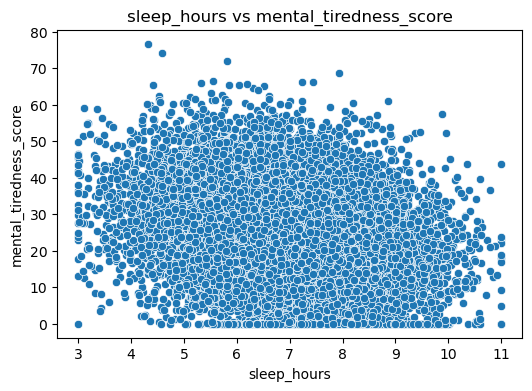

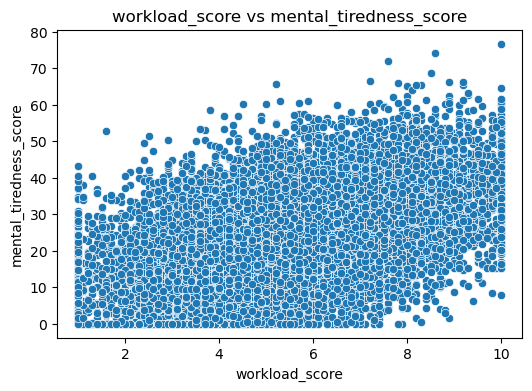

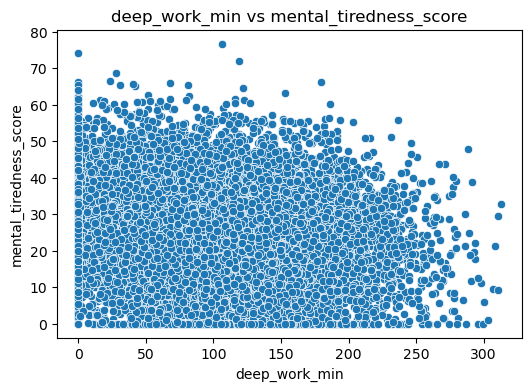

In [11]:

target = 'mental_tiredness_score'

features = [
    'screen_time_min',
    'sleep_hours',
    'workload_score',
    'deep_work_min'
]

for col in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df[target])

    plt.title(f'{col} vs {target}')
    plt.show()



### Output Description
Scatter plots show relationship between:
- Independent feature
- Target variable

Example insights:
- Higher workload may increase tiredness
- More sleep may reduce tiredness



# Step 6: Outlier Detection

### Description
Boxplots are used to identify extreme values in numerical columns.


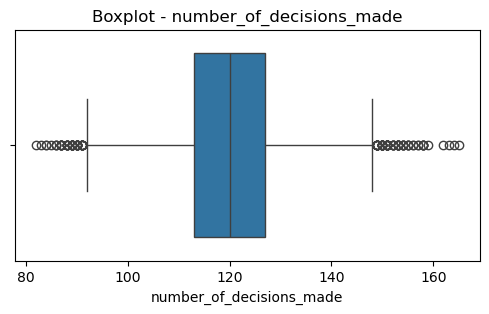

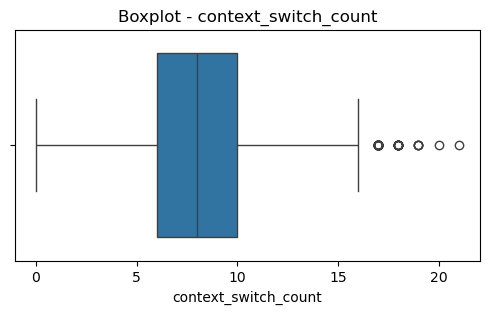

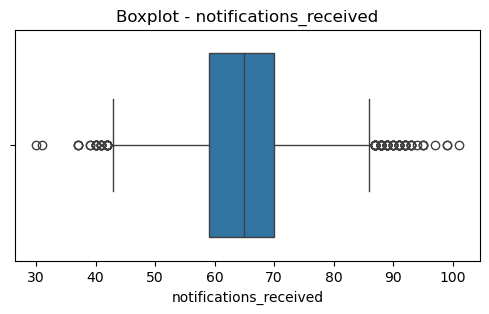

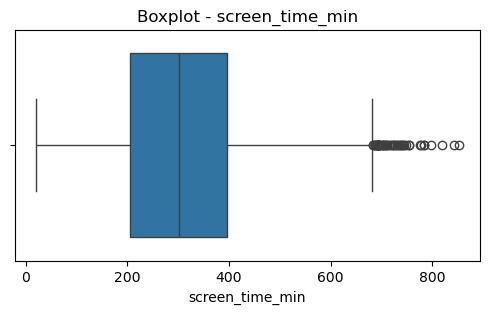

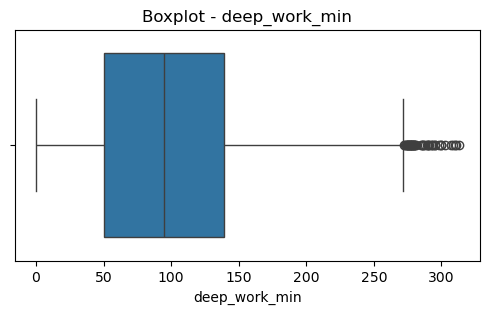

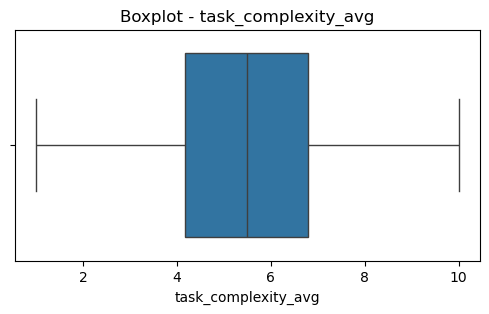

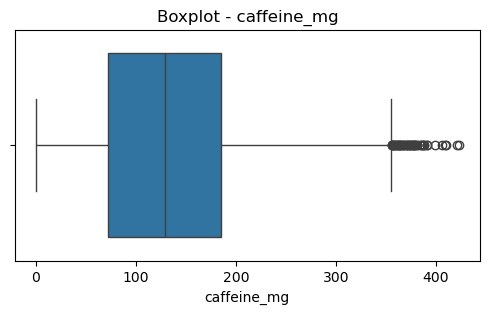

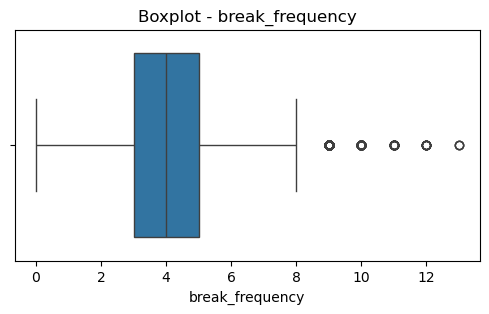

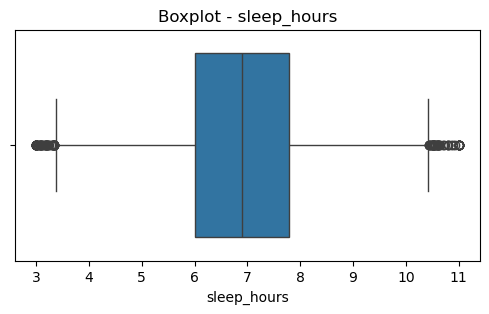

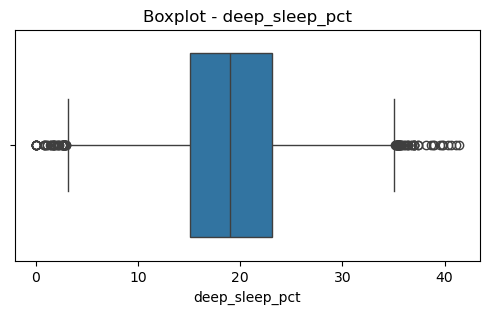

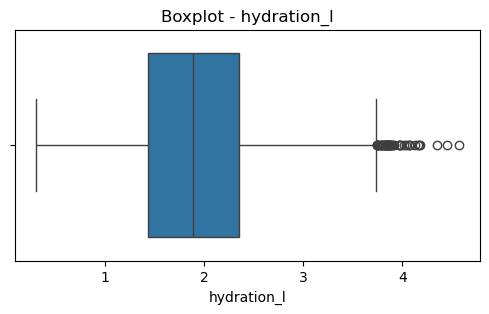

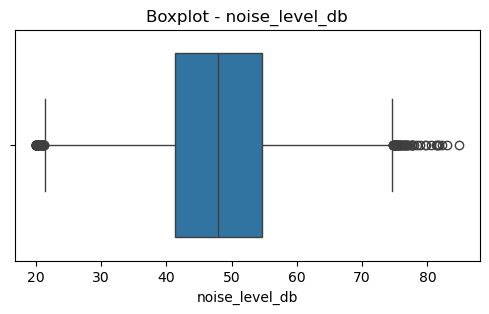

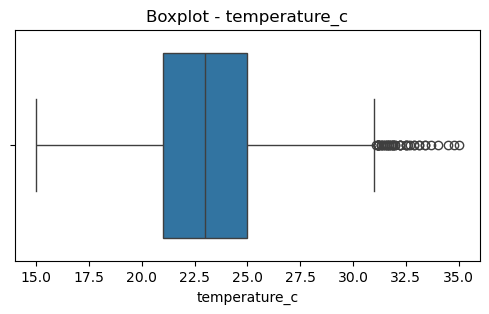

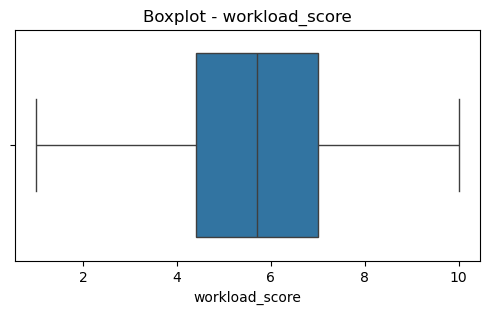

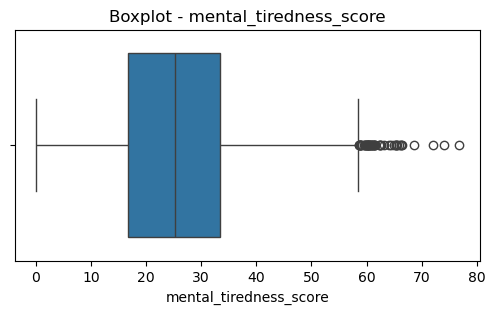

In [12]:

for col in num_cols:
    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot - {col}')
    plt.show()



### Output Description
In boxplots:
- Points outside whiskers are outliers

Outliers can:
- Distort model learning
- Reduce prediction accuracy



# Step 7: Outlier Treatment using IQR Method

### Description
We remove extreme values using the Interquartile Range (IQR) method.


In [13]:

def remove_outliers_iqr(data, columns):

    for col in columns:

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        data = data[(data[col] >= lower) & (data[col] <= upper)]

    return data

df = remove_outliers_iqr(df, num_cols)

print("Shape after outlier removal:", df.shape)


Shape after outlier removal: (13710, 18)



### Output Description
Dataset size after outlier removal is displayed.

If rows decrease:
- Extreme values were successfully removed
- Data becomes cleaner for machine learning



# Step 8: Feature Encoding

### Description
Machine learning models cannot understand text data directly.

Categorical columns are converted into numerical format using Label Encoding.


In [14]:

cat_cols = df.select_dtypes(include='object').columns

cat_cols


Index(['mood', 'work_type', 'work_environment'], dtype='object')


### Output Description
Displays all categorical columns that need encoding.


In [15]:

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()


,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
0,110,14,70,196.5,65.1,7.0,136.1,1,7.84,26.75,2.05,0,2,0,53.8,19.8,3.3,22.17
1,122,9,66,256.4,135.2,6.5,83.9,3,7.18,17.82,1.82,1,2,1,38.9,18.7,4.6,25.35
2,113,4,55,387.3,54.2,10.0,176.5,5,5.52,27.78,1.92,0,1,2,42.0,26.4,7.9,34.36
3,113,8,45,300.3,107.1,4.8,164.7,2,8.47,3.48,1.89,0,0,2,47.2,23.8,5.4,11.92
4,95,8,68,240.5,3.2,8.0,186.3,4,7.48,21.17,2.41,0,0,0,61.0,24.2,8.5,37.45



### Output Description
Text values are converted into numbers.

Example:
- Happy → 0
- Neutral → 1
- Low → 2

Now the dataset becomes machine-learning compatible.



# Step 9: Feature Scaling

### Description
Scaling ensures all features are on similar range.

We use StandardScaler:
- Mean becomes 0
- Standard deviation becomes 1


In [16]:

X = df.drop('mental_tiredness_score', axis=1)

y = df['mental_tiredness_score']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[-9.57085245e-01,  2.18140208e+00,  6.59911887e-01,
        -7.74273935e-01, -5.13245921e-01,  7.71250351e-01,
         7.02930521e-02, -1.55330242e+00,  7.52149000e-01,
         1.33091276e+00,  2.46024968e-01, -1.07395686e+00,
         1.57032146e-01, -1.12291962e+00,  6.09569029e-01,
        -1.08016865e+00, -1.23674120e+00],
       [ 1.82778693e-01,  3.81292382e-01,  1.41206332e-01,
        -3.28506227e-01,  6.46906352e-01,  5.15233792e-01,
        -5.96213737e-01, -4.72408288e-01,  2.27116585e-01,
        -2.10239576e-01, -9.36634203e-02,  4.46292186e-02,
         1.57032146e-01, -4.56802984e-03, -9.42627239e-01,
        -1.45593647e+00, -5.65299059e-01],
       [-6.72119260e-01, -1.41881731e+00, -1.28523394e+00,
         6.45633891e-01, -6.93640497e-01,  2.30734971e+00,
         5.86133556e-01,  6.08485842e-01, -1.09341949e+00,
         1.50867165e+00,  5.40271834e-02, -1.07395686e+00,
        -8.26481202e-01,  1.11378356e+00, -6.19687076e-01,
         1.17443826e+00,  1.1


### Output Description
Scaled feature values are displayed.

Benefits of scaling:
- Faster model convergence
- Better performance for distance-based algorithms
- Prevents dominance of large-value features



# Step 10: Train-Test Split

### Description
Dataset is divided into:
- Training data (80%)
- Testing data (20%)

Training data teaches the model.  
Testing data evaluates performance on unseen data.


In [17]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (10968, 17)
X_test shape: (2742, 17)



### Output Description
This output shows:
- Number of training samples
- Number of testing samples

Proper splitting helps evaluate real-world model performance.



# Sprint 1 Deliverables

## Completed Tasks
- Dataset loading
- Data inspection
- Missing value checking
- Duplicate removal
- EDA
- Correlation analysis
- Outlier handling
- Feature encoding
- Feature scaling
- Train-test split

## Conclusion
The dataset is now:
- Clean
- Structured
- Model-ready

This completes Sprint 1 successfully and prepares the project for Sprint 2: Model Building & Evaluation.
